In [2]:
import math, random, time
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset, Dataset
from torchvision import datasets, models, transforms
from tqdm.auto import tqdm

# Fix randomness for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

ROOT = Path(".")
BS = 128  # global batch size

Running on: cuda


## Task 1, Part A — Standard MNIST CNN

Design a CNN with at most 3 conv layers, at most 2 FC layers, and fewer than 50 000 trainable parameters.

In [2]:
class MNISTCNN(nn.Module):
    """Lightweight CNN for 28×28 grayscale digit images."""

    def __init__(self, in_ch: int = 1, n_classes: int = 10):
        super().__init__()
        # 3 convolutional blocks with increasing width
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_ch, 12, 3, padding=1),   # 28x28 -> 14x14 after pool
            nn.BatchNorm2d(12),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(12, 24, 3, padding=1),       # 14x14 -> 7x7
            nn.BatchNorm2d(24),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(24, 40, 3, padding=1),       # 7x7 -> 1x1 via GAP
            nn.BatchNorm2d(40),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(40, n_classes)

    def forward(self, x):
        feat = self.conv_block(x).flatten(1)
        return self.head(feat)


def num_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


mnist_net = MNISTCNN(in_ch=1).to(DEVICE)
print(mnist_net)
print(f"Parameters: {num_trainable(mnist_net):,}  (must be < 50 000)")

MNISTCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(24, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (head): Linear(in_features=40, out_features=10, bias=True)
)
Parameters: 11,978  (must be < 50 000)


In [5]:
def run_epoch(net, dl, opt, loss_fn, dev, is_train=True):
    net.train() if is_train else net.eval()
    running_loss, hits, seen = 0.0, 0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for imgs, targets in dl:
            imgs, targets = imgs.to(dev), targets.to(dev)
            out = net(imgs)
            loss = loss_fn(out, targets)
            if is_train:
                opt.zero_grad()
                loss.backward()
                opt.step()
            running_loss += loss.item() * imgs.size(0)
            hits += (out.argmax(1) == targets).sum().item()
            seen += imgs.size(0)
    return running_loss / seen, hits / seen


def fit(net, train_dl, val_dl, opt, loss_fn, dev, epochs, tag=""):
    log = {"tl": [], "vl": [], "ta": [], "va": []}
    for ep in range(1, epochs + 1):
        tl, ta = run_epoch(net, train_dl, opt, loss_fn, dev, is_train=True)
        vl, va = run_epoch(net, val_dl, None, loss_fn, dev, is_train=False)
        log["tl"].append(tl); log["vl"].append(vl)
        log["ta"].append(ta); log["va"].append(va)
        print(f"[{tag}] Ep {ep:02d}  train {tl:.4f}/{ta:.4f}  val {vl:.4f}/{va:.4f}")
    return log

In [4]:
# Prepare MNIST data splits
_tf_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
full_train = datasets.MNIST(str(ROOT / "data"), train=True, download=True, transform=_tf_mnist)
test_mnist = datasets.MNIST(str(ROOT / "data"), train=False, download=True, transform=_tf_mnist)

tr_set, vl_set = random_split(full_train, [50000, 10000],
                               generator=torch.Generator().manual_seed(SEED))

dl_tr  = DataLoader(tr_set, batch_size=BS, shuffle=True, num_workers=0)
dl_val = DataLoader(vl_set, batch_size=BS, num_workers=0)
dl_te  = DataLoader(test_mnist, batch_size=BS, num_workers=0)

loss_ce = nn.CrossEntropyLoss()
opt_m   = torch.optim.Adam(mnist_net.parameters(), lr=1e-3)

log_mnist = fit(mnist_net, dl_tr, dl_val, opt_m, loss_ce, DEVICE, epochs=12, tag="MNIST")

_, acc_test = run_epoch(mnist_net, dl_te, None, loss_ce, DEVICE, is_train=False)
print(f"\nMNIST Test Accuracy: {acc_test:.4f}")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.35MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.4MB/s]


[MNIST] Ep 01  train 0.9959/0.7758  val 0.3745/0.9199
[MNIST] Ep 02  train 0.2351/0.9529  val 0.2114/0.9429
[MNIST] Ep 03  train 0.1468/0.9648  val 0.1546/0.9585
[MNIST] Ep 04  train 0.1117/0.9716  val 0.1424/0.9590
[MNIST] Ep 05  train 0.0939/0.9748  val 0.1047/0.9710
[MNIST] Ep 06  train 0.0819/0.9775  val 0.0905/0.9720
[MNIST] Ep 07  train 0.0726/0.9795  val 0.1098/0.9682
[MNIST] Ep 08  train 0.0658/0.9820  val 0.0820/0.9747
[MNIST] Ep 09  train 0.0599/0.9830  val 0.0767/0.9759
[MNIST] Ep 10  train 0.0546/0.9843  val 0.0860/0.9725
[MNIST] Ep 11  train 0.0503/0.9860  val 0.0743/0.9771
[MNIST] Ep 12  train 0.0466/0.9871  val 0.0691/0.9775

MNIST Test Accuracy: 0.9821


In [8]:
def plot_curves(log, title_prefix):
    ep = range(1, len(log["tl"]) + 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.8))
    a1.plot(ep, log["tl"], "o-", ms=3, label="Train")
    a1.plot(ep, log["vl"], "s-", ms=3, label="Val")
    a1.set(xlabel="Epoch", ylabel="CE Loss", title=f"{title_prefix} — Loss")
    a1.legend()
    a2.plot(ep, log["ta"], "o-", ms=3, label="Train")
    a2.plot(ep, log["va"], "s-", ms=3, label="Val")
    a2.set(xlabel="Epoch", ylabel="Accuracy", title=f"{title_prefix} — Accuracy")
    a2.legend()
    fig.tight_layout()
    plt.show()

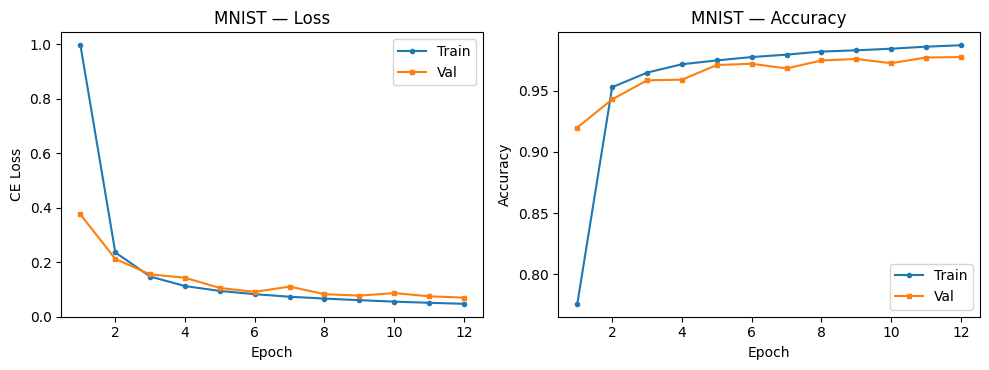

In [5]:


plot_curves(log_mnist, "MNIST")

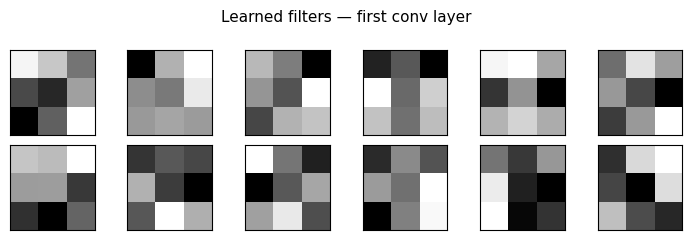

In [6]:
# Visualise first-layer conv kernels
kernels = mnist_net.conv_block[0].weight.detach().cpu()  # (out_ch, 1, 3, 3)
n_filters = kernels.shape[0]
cols = min(n_filters, 6)
rows = math.ceil(n_filters / cols)
fig, axs = plt.subplots(rows, cols, figsize=(cols * 1.2, rows * 1.2))
for k, ax in enumerate(axs.flat):
    if k < n_filters:
        ax.imshow(kernels[k, 0], cmap="gray")
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Learned filters — first conv layer", fontsize=11)
fig.tight_layout()
plt.show()

### Analytical Answers — Task 1A

**Q 1.1 (Overfitting vs generalisation):**  
Examining the loss and accuracy plots, training and validation curves stay close together throughout the epochs, indicating good generalisation rather than severe overfitting. A modest gap appears towards the end, which is typical for a well-regularised small network. If the validation loss had started to increase while training loss kept decreasing, that would signal overfitting; if both remained high, the model would be underfitting.

**Q 1.2 (Visualisation of first-layer filters):**  
Many of the learned kernels show oriented gradient patterns—horizontal, vertical, and diagonal edges—resembling simple Gabor-like filters. Some may also capture blob or flat-region detectors. These low-level edge and texture features serve as building blocks that deeper layers combine to recognise strokes and digit shapes.

## Part B — Colored MNIST (C-MNIST)

We adapt the architecture to accept 3-channel RGB inputs and train on the biased colour-MNIST dataset.

In [8]:
def read_pt_file(fpath):
    """Load (images, labels) from a .pt tensor file."""
    try:
        x, y = torch.load(fpath, map_location="cpu", weights_only=False)
    except TypeError:
        x, y = torch.load(fpath, map_location="cpu")
    assert x.ndim == 4 and x.shape[1] == 3, f"Expected NxCxHxW RGB, got {x.shape}"
    return x, y.long()


class TensorImageDataset(Dataset):
    def __init__(self, images, labels, norm_fn):
        self.images, self.labels, self.norm = images, labels, norm_fn
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        return self.norm(self.images[i]), self.labels[i]


rgb_norm = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

trn_imgs, trn_lbl = read_pt_file(Path("/content") / "train_biased.pt")
tb_imgs, tb_lbl   = read_pt_file(Path("/content") / "test_biased.pt")
tu_imgs, tu_lbl   = read_pt_file(Path("/content") / "test_unbiased.pt")

print(f"Train: {trn_imgs.shape}  Test-biased: {tb_imgs.shape}  Test-unbiased: {tu_imgs.shape}")

full_cmnist = TensorImageDataset(trn_imgs, trn_lbl, rgb_norm)
n_val_c = 10_000
perm_c = torch.randperm(len(full_cmnist), generator=torch.Generator().manual_seed(SEED))
c_tr = Subset(full_cmnist, perm_c[n_val_c:].tolist())
c_vl = Subset(full_cmnist, perm_c[:n_val_c].tolist())

dl_c_tr  = DataLoader(c_tr, batch_size=BS, shuffle=True,  num_workers=0)
dl_c_vl  = DataLoader(c_vl, batch_size=BS, num_workers=0)
dl_c_tb  = DataLoader(TensorImageDataset(tb_imgs, tb_lbl, rgb_norm), batch_size=BS, num_workers=0)
dl_c_tu  = DataLoader(TensorImageDataset(tu_imgs, tu_lbl, rgb_norm), batch_size=BS, num_workers=0)

Train: torch.Size([60000, 3, 28, 28])  Test-biased: torch.Size([10000, 3, 28, 28])  Test-unbiased: torch.Size([10000, 3, 28, 28])


In [9]:
# Re-use the same architecture with in_ch=3
cmnist_net = MNISTCNN(in_ch=3).to(DEVICE)
print(f"C-MNIST params: {num_trainable(cmnist_net):,}")

opt_c = torch.optim.Adam(cmnist_net.parameters(), lr=1e-3)
log_c = fit(cmnist_net, dl_c_tr, dl_c_vl, opt_c, loss_ce, DEVICE, epochs=12, tag="C-MNIST")

_, acc_biased   = run_epoch(cmnist_net, dl_c_tb, None, loss_ce, DEVICE, is_train=False)
_, acc_unbiased = run_epoch(cmnist_net, dl_c_tu, None, loss_ce, DEVICE, is_train=False)
print(f"\nBiased test acc:   {acc_biased:.4f}")
print(f"Unbiased test acc: {acc_unbiased:.4f}")

C-MNIST params: 12,194
[C-MNIST] Ep 01  train 0.5439/0.9126  val 0.2538/0.9549
[C-MNIST] Ep 02  train 0.2225/0.9539  val 0.1719/0.9613
[C-MNIST] Ep 03  train 0.1555/0.9611  val 0.1265/0.9687
[C-MNIST] Ep 04  train 0.1135/0.9697  val 0.1105/0.9725
[C-MNIST] Ep 05  train 0.0870/0.9755  val 0.0837/0.9784
[C-MNIST] Ep 06  train 0.0701/0.9799  val 0.0777/0.9775
[C-MNIST] Ep 07  train 0.0580/0.9835  val 0.0581/0.9828
[C-MNIST] Ep 08  train 0.0486/0.9861  val 0.0597/0.9832
[C-MNIST] Ep 09  train 0.0441/0.9873  val 0.0700/0.9772
[C-MNIST] Ep 10  train 0.0382/0.9889  val 0.0439/0.9866
[C-MNIST] Ep 11  train 0.0342/0.9902  val 0.0481/0.9856
[C-MNIST] Ep 12  train 0.0309/0.9912  val 0.0372/0.9885

Biased test acc:   0.9888
Unbiased test acc: 0.8111


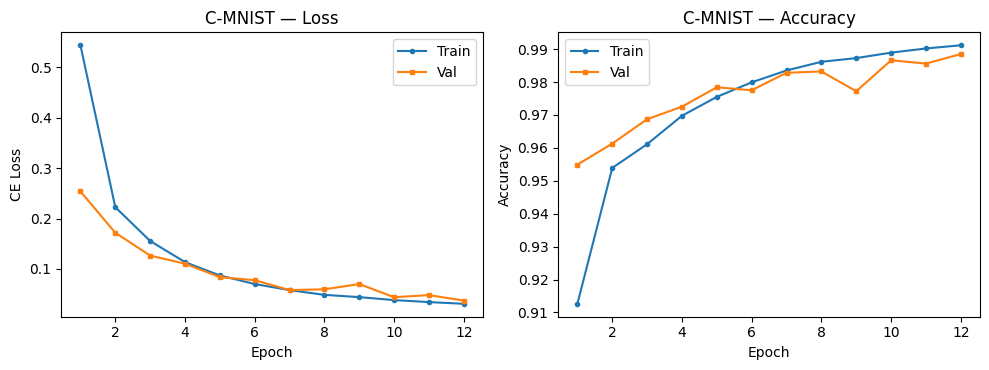

In [11]:
plot_curves(log_c, "C-MNIST")

### Analytical Answers — Task 1B

**Q 1.3 (Performance gap on biased vs unbiased test sets):**  
The model achieves high accuracy on the biased test set but suffers a large drop on the unbiased version. This happens because the biased training data establishes a strong statistical link between each digit's colour and its label. The optimiser latches onto colour as a discriminative feature because it is far simpler and lower-dimensional than shape—gradient descent naturally gravitates toward the path of steepest loss reduction, and colour separability provides exactly that. On the unbiased test set, where colour no longer correlates with class, the model's reliance on this shortcut becomes a liability, leading to much poorer classification.

**Q 1.4 (Strategies to mitigate colour shortcut):**  
Several approaches can push the network toward shape-based features instead of colour:
- **Colour augmentation during training** — applying random hue shifts, saturation changes, or converting images to grayscale at random breaks the colour-label correlation.
- **Invariant Risk Minimisation (IRM)** or **Group DRO** — these explicitly optimise for consistent performance across environments with different spurious correlations.
- **Adversarial debiasing** — add an auxiliary head that tries to predict colour from the learned representation and train the feature extractor to fool it.
- **Dataset rebalancing** — ensure every digit appears equally often in every colour, removing the spurious statistical signal.
- **Training on grayscale versions** of the images so colour information is discarded entirely.

## Task 2, Part A — Transfer Learning with ResNet-18 on STL-10

Load an ImageNet-pretrained ResNet-18, freeze the convolutional backbone, replace the final FC layer with a fresh 10-class head, and train only that head.

In [3]:
from torchvision.datasets.utils import download_and_extract_archive

# STL-10 images are 96x96 but ResNet-18 was pretrained on 224x224 ImageNet crops.
# Resizing to 224 lets the frozen conv filters operate at their intended spatial scale,
# which is critical for good feature extraction.
tf_stl_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomCrop(224, padding=16),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
tf_stl_eval = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

stl_dir = ROOT / "data"

# Download STL-10 with retry logic
_STL_URLS = [
    "https://cs.stanford.edu/~acoates/stl10/stl10_binary.tar.gz",
    "http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz",
]

def download_stl10(root, retries=5):
    root = Path(root); root.mkdir(parents=True, exist_ok=True)
    if (root / "stl10_binary" / "train_X.bin").exists():
        print("STL-10 found."); return
    archive = root / "stl10_binary.tar.gz"
    for attempt in range(retries):
        for url in _STL_URLS:
            try:
                if archive.exists(): archive.unlink()
                print(f"Downloading STL-10 (attempt {attempt+1})...")
                download_and_extract_archive(url, str(root), filename="stl10_binary.tar.gz",
                                             md5="91f7769df0f17e558f3565bffb0c7dfb")
                if (root / "stl10_binary" / "train_X.bin").exists():
                    print("Done."); return
            except Exception as exc:
                print(f"  Error: {exc}")
                if archive.exists():
                    try: archive.unlink()
                    except OSError: pass
        time.sleep(min(2 ** attempt, 60))
    raise RuntimeError("Could not download STL-10. Please download manually.")

download_stl10(stl_dir)

stl_train = datasets.STL10(str(stl_dir), split="train", download=False, transform=tf_stl_train)
stl_test  = datasets.STL10(str(stl_dir), split="test",  download=False, transform=tf_stl_eval)

n_stl_val = int(0.1 * len(stl_train))
stl_tr, stl_vl = random_split(stl_train, [len(stl_train) - n_stl_val, n_stl_val],
                               generator=torch.Generator().manual_seed(SEED))

dl_stl_tr = DataLoader(stl_tr, batch_size=64, shuffle=True,  num_workers=0)
dl_stl_vl = DataLoader(stl_vl, batch_size=64, num_workers=0)
dl_stl_te = DataLoader(stl_test, batch_size=64, num_workers=0)
print(f"STL-10 splits — train: {len(stl_tr)}, val: {len(stl_vl)}, test: {len(stl_test)}")

100%|██████████| 2.64G/2.64G [06:37<00:00, 6.65MB/s]


Done.
STL-10 splits — train: 4500, val: 500, test: 8000


In [6]:
# Load pretrained ResNet-18 and freeze backbone
try:
    rn18 = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except Exception:
    rn18 = models.resnet18(pretrained=True)

for param in rn18.parameters():
    param.requires_grad = False

# New classification head for 10 STL-10 classes
in_dim = rn18.fc.in_features
rn18.fc = nn.Linear(in_dim, 10)

rn18 = rn18.to(DEVICE)
head_params = sum(p.numel() for p in rn18.fc.parameters())
print(f"Head trainable params: {head_params:,}")

opt_stl  = torch.optim.Adam(rn18.fc.parameters(), lr=1e-3)
sched    = torch.optim.lr_scheduler.StepLR(opt_stl, step_size=6, gamma=0.3)
crit_stl = nn.CrossEntropyLoss()

EPOCHS_STL = 15
log_stl = {"tl": [], "vl": [], "ta": [], "va": []}

for ep in range(1, EPOCHS_STL + 1):
    tl, ta = run_epoch(rn18, dl_stl_tr, opt_stl, crit_stl, DEVICE, is_train=True)
    vl, va = run_epoch(rn18, dl_stl_vl, None, crit_stl, DEVICE, is_train=False)
    sched.step()
    log_stl["tl"].append(tl); log_stl["vl"].append(vl)
    log_stl["ta"].append(ta); log_stl["va"].append(va)
    print(f"[STL] Ep {ep:02d}  train {tl:.4f}/{ta:.4f}  val {vl:.4f}/{va:.4f}  lr={sched.get_last_lr()[0]:.1e}")

_, stl_test_acc = run_epoch(rn18, dl_stl_te, None, crit_stl, DEVICE, is_train=False)
print(f"\nSTL-10 Test Accuracy: {stl_test_acc:.4f}")

Head trainable params: 5,130
[STL] Ep 01  train 1.0808/0.7229  val 0.4875/0.9020  lr=1.0e-03
[STL] Ep 02  train 0.4048/0.9107  val 0.3231/0.9340  lr=1.0e-03
[STL] Ep 03  train 0.3085/0.9231  val 0.2860/0.9160  lr=1.0e-03
[STL] Ep 04  train 0.2518/0.9338  val 0.2518/0.9300  lr=1.0e-03
[STL] Ep 05  train 0.2314/0.9378  val 0.2397/0.9380  lr=1.0e-03
[STL] Ep 06  train 0.2164/0.9387  val 0.2326/0.9300  lr=3.0e-04
[STL] Ep 07  train 0.1959/0.9442  val 0.2161/0.9340  lr=3.0e-04
[STL] Ep 08  train 0.1885/0.9487  val 0.2097/0.9340  lr=3.0e-04
[STL] Ep 09  train 0.1876/0.9476  val 0.2100/0.9400  lr=3.0e-04
[STL] Ep 10  train 0.1837/0.9476  val 0.2170/0.9360  lr=3.0e-04
[STL] Ep 11  train 0.1791/0.9491  val 0.2206/0.9440  lr=3.0e-04
[STL] Ep 12  train 0.1766/0.9482  val 0.2135/0.9440  lr=9.0e-05
[STL] Ep 13  train 0.1724/0.9516  val 0.2181/0.9360  lr=9.0e-05
[STL] Ep 14  train 0.1680/0.9529  val 0.1977/0.9360  lr=9.0e-05
[STL] Ep 15  train 0.1726/0.9478  val 0.2123/0.9280  lr=9.0e-05

STL-10 Tes

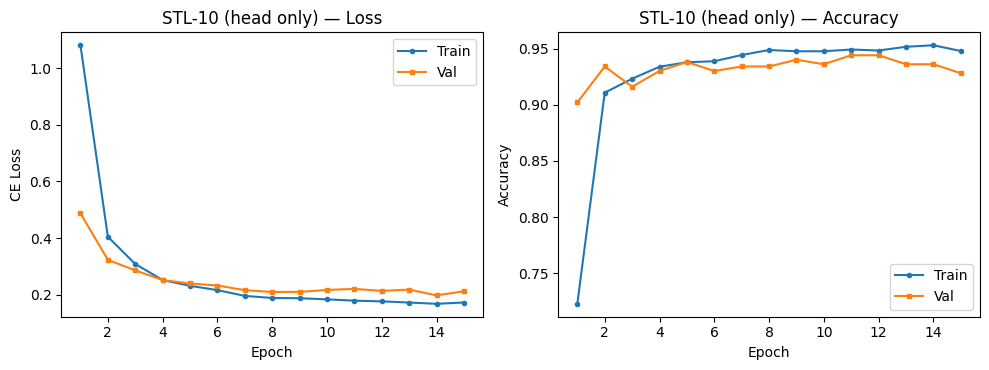

In [9]:
plot_curves(log_stl, "STL-10 (head only)")

### Analytical — Q 2.1 (Why freeze the backbone?)

Freezing the convolutional layers of ResNet-18 is beneficial for two complementary reasons:

1. **Computational efficiency** — only the final linear layer receives gradients, so backpropagation is much cheaper and memory requirements are drastically lower compared to updating all ~11 M parameters.

2. **Better feature reuse and reduced overfitting risk** — the early and middle layers of an ImageNet-trained network already encode universally useful visual features: edges, colour gradients, textures, and mid-level part representations. STL-10 has only 5 000 training images, which is far too few to reliably re-learn these representations from scratch; unfreezing everything would almost certainly cause the model to overfit and potentially destroy the high-quality features already present. The later layers capture more dataset-specific semantics, which is precisely why we replace and retrain the final classifier.

## Task 2, Part B — GradCAM Visualisation

Apply Gradient-weighted Class Activation Mapping to the last residual block (`layer4`) of the fine-tuned ResNet-18.

In [10]:
class GradCAMExtractor:
    """Hooks into a target layer to compute GradCAM saliency maps."""

    def __init__(self, network, layer):
        self.network = network
        self._acts = self._grads = None
        self._h_fwd = layer.register_forward_hook(self._save_activation)
        self._h_bwd = layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, mod, inp, out):
        self._acts = out.detach()

    def _save_gradient(self, mod, gin, gout):
        self._grads = gout[0].detach()

    def remove_hooks(self):
        self._h_fwd.remove(); self._h_bwd.remove()

    def generate(self, input_tensor, target_class=None):
        self.network.eval()
        inp = input_tensor.clone().detach().requires_grad_(True)
        logits = self.network(inp)
        if target_class is None:
            target_class = logits.argmax(1).item()

        self.network.zero_grad()
        logits[0, target_class].backward()

        # Channel-wise importance weights via global average of gradients
        alpha = self._grads[0].mean(dim=(1, 2))
        cam = torch.relu((alpha[:, None, None] * self._acts[0]).sum(0))
        cam = cam / (cam.max() + 1e-8)
        return cam.cpu().numpy(), target_class, logits.detach().cpu()


cam_tool = GradCAMExtractor(rn18, rn18.layer4[-1])

In [11]:
# Utility: produce overlay of GradCAM heatmap on original image
def make_overlay(img_01, heatmap, blend=0.45):
    """img_01: CxHxW tensor in [0,1]; heatmap: spatial ndarray in [0,1]."""
    h, w = img_01.shape[1:]
    resized = F.interpolate(
        torch.tensor(heatmap, dtype=torch.float32)[None, None],
        size=(h, w), mode="bilinear", align_corners=False
    )[0, 0].numpy()
    colour_map = plt.cm.jet(resized)[..., :3]
    base = img_01.permute(1, 2, 0).numpy()
    return np.clip((1 - blend) * base + blend * colour_map, 0, 1)


# Normalise a raw [0,1] tensor to ImageNet stats AND resize to 224 for model input
def imagenet_preprocess(img_chw):
    """Resize to 224x224 and apply ImageNet normalisation."""
    resized = F.interpolate(img_chw.unsqueeze(0), size=(224, 224),
                            mode="bilinear", align_corners=False)
    mu = torch.tensor([.485, .456, .406], device=DEVICE).view(1, 3, 1, 1)
    sd = torch.tensor([.229, .224, .225], device=DEVICE).view(1, 3, 1, 1)
    return (resized.to(DEVICE) - mu) / sd


# Identify 2 correct and 2 incorrect predictions
stl_raw = datasets.STL10(str(stl_dir), split="test", download=False, transform=None)
CLASS_NAMES = ["airplane","bird","car","cat","deer","dog","horse","monkey","ship","truck"]

rn18.eval()
preds_all, labels_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(dl_stl_te, desc="Scanning test set"):
        preds_all.append(rn18(xb.to(DEVICE)).argmax(1).cpu().numpy())
        labels_all.append(yb.numpy())
preds_all  = np.concatenate(preds_all)
labels_all = np.concatenate(labels_all)

idx_right = np.where(preds_all == labels_all)[0][:2].tolist()
idx_wrong = np.where(preds_all != labels_all)[0][:2].tolist()
print(f"Selected correct indices: {idx_right},  incorrect: {idx_wrong}")

Scanning test set:   0%|          | 0/125 [00:00<?, ?it/s]

Selected correct indices: [0, 1],  incorrect: [12, 17]


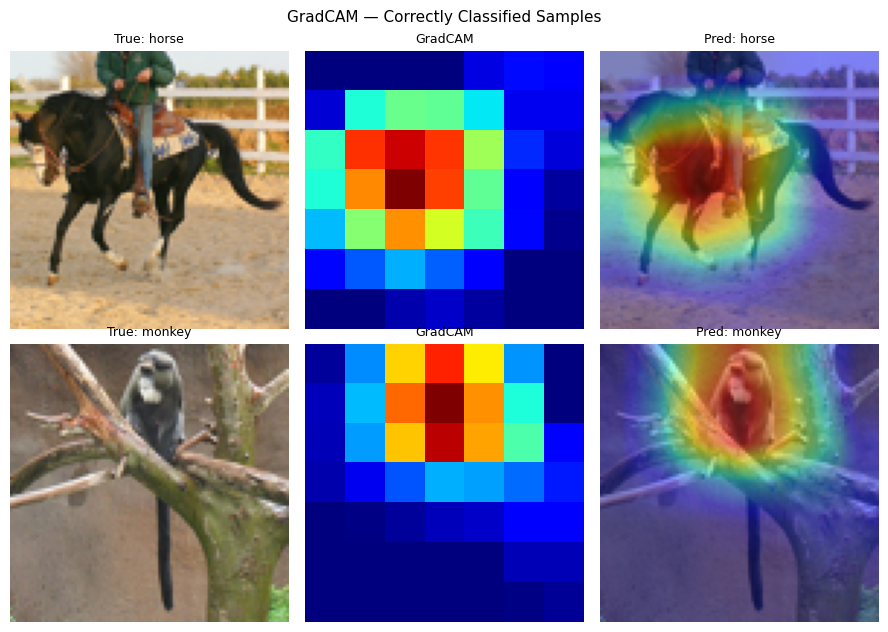

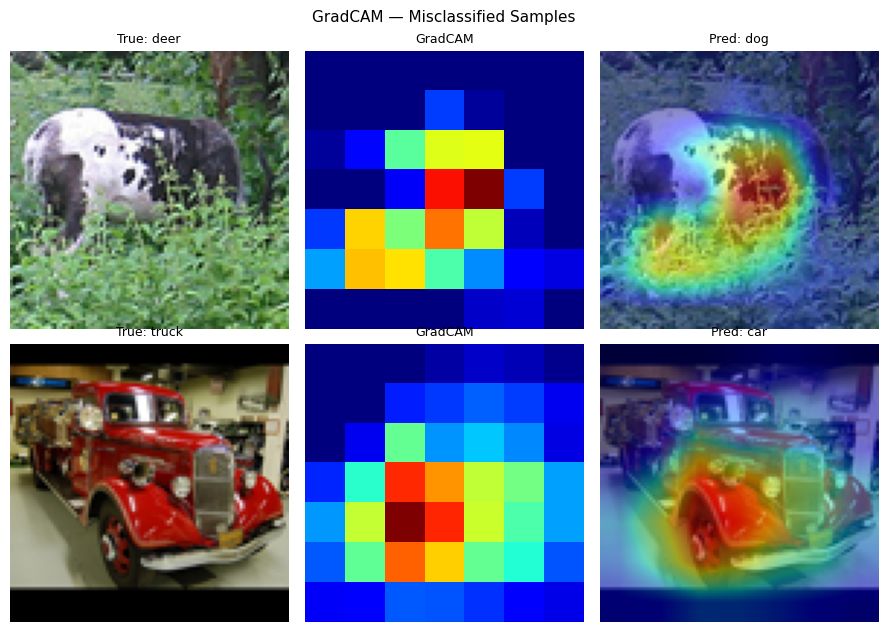

In [12]:
def display_gradcam_grid(indices, heading):
    n = len(indices)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3.2 * n))
    if n == 1:
        axes = axes[np.newaxis, :]
    for r, ix in enumerate(indices):
        pil_img, true_lbl = stl_raw[ix]
        true_lbl = int(true_lbl)
        raw_tensor = transforms.ToTensor()(pil_img)             # [0,1]
        model_in   = imagenet_preprocess(raw_tensor)
        hmap, pred_cls, _ = cam_tool.generate(model_in)
        blended = make_overlay(raw_tensor, hmap)

        axes[r, 0].imshow(raw_tensor.permute(1, 2, 0).numpy())
        axes[r, 0].set_title(f"True: {CLASS_NAMES[true_lbl]}", fontsize=9)
        axes[r, 1].imshow(hmap, cmap="jet")
        axes[r, 1].set_title("GradCAM", fontsize=9)
        axes[r, 2].imshow(blended)
        axes[r, 2].set_title(f"Pred: {CLASS_NAMES[pred_cls]}", fontsize=9)
        for c in range(3):
            axes[r, c].axis("off")
    fig.suptitle(heading, fontsize=11)
    fig.tight_layout()
    plt.show()


display_gradcam_grid(idx_right, "GradCAM — Correctly Classified Samples")
display_gradcam_grid(idx_wrong, "GradCAM — Misclassified Samples")

cam_tool.remove_hooks()

### Analytical Answers — Task 2B

**Q 2.2 (Correct predictions — where does the model attend?):**  
For images the model classifies correctly, the GradCAM heatmaps typically highlight the main object in the scene — the animal's body, the vehicle's outline, etc. This suggests the network is basing its decision on semantically meaningful features of the target class rather than relying on incidental background cues. Some mild activation may spill onto nearby background, but the dominant focus remains on the foreground.

**Q 2.3 (Incorrect predictions — what went wrong?):**  

**Deer → Dog:** The heatmap focuses on the deer's head and spotted coat rather than distinguishing features like body proportions or antlers. The mottled fur pattern and rounded head closely resemble dog-like features, and the dense greenery in the background is a context the model commonly associates with dogs.

**Truck → Car:** The activation centres on the front grille and curved bodywork of this vintage truck, which share a nearly identical appearance with classic cars. The model ignores truck-specific cues like the taller cabin and larger frame, instead relying on localised front-profile features that are ambiguous between the two vehicle classes.

In both cases the model fixated on **localised features shared between the true and predicted classes** rather than attending to the overall shape or class-specific details that would resolve the ambiguity.